# caso EverPeak

## Conteo de valores faltantes por columna

Objetivo: Contar cuántos valores faltantes tiene cada variable de segmentación y ubicación, usando sumas, no porcentajes.

Instrucciones:

Calcula cuántos valores faltantes tienen las columnas payment_method, city y state.
Crea una variable distinta por columna.
Usa print() para mostrar el resultado de cada variable en una línea separada.

In [1]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

payment_missing = df['payment_method'].isna().sum()
city_missing = df['city'].isna().sum()
state_missing = df['state'].isna().sum()

print("payment_method missing:", payment_missing)
print("city missing:", city_missing)
print("state missing:", state_missing)

payment_method missing: 0
city missing: 100
state missing: 100


## Fechas sospechosas y montos extremos

Objetivo: Medir cuántos registros tienen fechas sospechosas y montos anormalmente altos.

Instrucciones:

Convierte la columna order_date a formato fecha, tratando los errores como valores faltantes.
Usando .sum(), calcula cuántos registros tienen como año 2026 en order_date (un año no transcurrido al guardar los datos).
Usando .sum(), calcula cuántos registros tienen order_date vacía después de la conversión.
Imprime cada conteo por separado con print().

In [3]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

df["order_date"] = pd.to_datetime(df["order_date"], errors='coerce')

invalid_year_2026_count = (df["order_date"].dt.year == 2026).sum()
missing_order_date_count = df["order_date"].isna().sum()

print("order_date año 2026:", invalid_year_2026_count)
print("order_date missing:", missing_order_date_count)

order_date año 2026: 15
order_date missing: 8


## Cardinalidad en columnas de cliente

Objetivo: Calcular la cardinalidad de columnas clave para entender si son IDs, categorías o variables poco útiles.

Instrucciones:

Calcula cuántos valores únicos tiene customer_id.
Calcula cuántos valores únicos tiene payment_method.
Calcula cuántos valores únicos tienen city y state (cada una por separado).
Imprime cada resultado con print(), mostrando el nombre de la columna y su número de valores únicos.

In [4]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

customer_id_unicos = nunique_col = df["customer_id"].nunique()
payment_unicos =  nunique_col = df["payment_method"].nunique()
city_unicos =  nunique_col = df["city"].nunique()
state_unicos =  nunique_col = df["state"].nunique()

print("customer_id nunique:", customer_id_unicos)
print("payment_method nunique:", payment_unicos)
print("city nunique:", city_unicos)
print("state nunique:", state_unicos)

customer_id nunique: 1829
payment_method nunique: 4
city nunique: 10
state nunique: 9


## Detectar patrones de missingness por grupo

Objetivo: Evaluar si el missing de city depende de alguna variable del negocio.

Instrucciones:

Calcula el porcentaje de valores faltantes de city por payment_method.
Observa los porcentajes para decidir si el patrón parece MCAR, MAR o MNAR.

In [5]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

missing_city_by_pay = df['city'].isna().groupby(df['payment_method']).mean() * 100


print(missing_city_by_pay)

payment_method
cash           2.010050
credit_card    2.151714
debit_card     2.130045
paypal         1.531915
Name: city, dtype: float64


## Comparar impacto entre drop e imputación

Objetivo: Medir cómo cambia la métrica cuando imputas o eliminas datos.

Instrucciones:

Calcula la media o promedio de order_value después de eliminar las filas con missing usando dropna().
Imputa los missing de order_value con la mediana.
Vuelve a calcular la media y compárala con la original.

In [6]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

before = df["order_value"].dropna().mean()
median_value = df["order_value"].median()
df["order_value_imputed"] = df["order_value"].fillna(median_value)
after = df["order_value_imputed"].mean()

print(before)
print(after)

10071.564696485622
10071.564696485622


## Comparar tres versiones de una columna numérica para decidir la estrategia final.

Instrucciones:

Tomando la columna numérica con missing: customer_age.
Calcula:
la media original,
la media imputando mediana,
y la media imputando media.
Analiza cuál estrategia es más apropiada para el caso EverPeak–SilverBasket.

In [7]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

before = df["customer_age"].dropna().mean()

median_value = df["customer_age"].median()
df["customer_age_med"] = df["customer_age"].fillna(median_value)
after_med = df["customer_age_med"].mean()

mean_value = df["customer_age"].mean()
df["customer_age_mean"] = df["customer_age"].fillna(mean_value)
after_mean = df["customer_age_mean"].mean()

print(before)
print(after_med)
print(after_mean)

43.72869493618773
43.88658146964856
43.728694936187736


## Tu primera función matemática

Objetivo: Crear tu primera función sencilla para generar confianza.

Instrucciones:

Define una función cube(x).
La función debe retornar el valor al cubo (multiplicar un número por sí mismo tres veces).
Llámala usando tres valores distintos 2, 5, -4 e imprime el resultado.

In [9]:
def cube(x):
    return x * x * x 

print(cube(2))
print(cube(5))
print(cube(-4))

8
125
-64


## Funciones aplicadas a texto

Objetivo: Practicar funciones usando cadenas.

Instrucciones:

Escribe una función format_name(name) que:

Elimine espacios al inicio y fin.
Convierta el texto a minúsculas.
Retorne la cadena limpia.
Pruébala con tres nombres distintos: " ANA ", "LuIs " y " CARLA" e imprime el resultado.

In [10]:
def format_name(name):
    return name.strip().lower()

print(format_name("  ANA  "))
print(format_name("LuIs "))
print(format_name(" CARLA"))

ana
luis
carla


## Funciones numéricas reutilizables

Objetivo: Construir una función simple para afianzar el patrón.

Instrucciones:

Define una función triple(x) que:

Reciba un número y devuelva el triple (el número multiplicado por 3).
Pruébala con 3 valores distintos: 1, 10 y -4 e imprime el resultado.

In [11]:
def triple(x):
    return x * 3

print(triple(1))
print(triple(10))
print(triple(-4))

3
30
-12


## Funciones con lógica personalizada

Objetivo: Comprender que las funciones pueden contener cualquier tipo de lógica, mientras reciban parámetros y retornen algo.

Instrucciones:

Crea una función greet(name) que:

Tome un nombre.
Devuelva "Hola, <nombre>!". usando f-string.
Llama a la función con 3 nombres distintos: Ana, Luis, Carla e imprime el resultado.

In [12]:
def greet(name):
     return f"Hola, {name}!"

print(greet("Ana"))
print(greet("Luis"))
print(greet("Carla"))

Hola, Ana!
Hola, Luis!
Hola, Carla!


## Bucle sobre una lista

Objetivo: Usar un for para recorrer una lista sencilla.

Instrucciones:

Crea una lista con 3 animales: 'perro', 'gato', 'loro'.
Usa un bucle for para imprimir Animal: <nombre> para cada uno (no uses f string).

In [13]:
# 1. Crea la lista de animales
animales = ["perro", "gato", "loro"]

# 2. Recorre la lista e imprime cada uno
for animal in animales:
    print("Animal:", animal)

Animal: perro
Animal: gato
Animal: loro


## Recorrer un string carácter por carácter

Objetivo: Entender que un string también es una colección.

Instrucciones:

Toma el texto "esternocleidomastoideo".
Usa un bucle for para imprimir cada letra en una línea.
Iterarás cada letra en el texto.

In [14]:
texto = "esternocleidomastoideo"

# Recorre el string letra por letra
for letra in texto: 
    print(letra)

e
s
t
e
r
n
o
c
l
e
i
d
o
m
a
s
t
o
i
d
e
o


## Usar while con contador

Objetivo: Dominar el uso básico de while y evitar bucles infinitos.

Instrucciones:

Define una variable contador que inicie en 5.
Mientras contador sea mayor que 0:
Imprime "Contador: <valor>".
Resta 1 al contador.

In [15]:
contador = 5

while contador > 0:
    print(contador)
    contador -= 1

5
4
3
2
1


## Convertir a numérico múltiples columnas

Objetivo: Aplicar una misma transformación a varias columnas usando una función + un bucle interno.

Instrucciones:

Crea una lista llamada columnas_numericas con:
"price", "quantity", "order_value"

Llama a la función convertir_columnas_numericas(df, columnas_numericas).
Revisa el resultado con df.info().

In [16]:
import pandas as pd
df = pd.read_csv('/datasets/everpeak_retail.csv')

# Ya tienes esta función disponible:
def convertir_columnas_numericas(df, columnas):
    for col in columnas:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

# ----------- TU CÓDIGO COMIENZA AQUÍ ----------- 

# 1. Crear la lista de columnas numéricas
columnas_numericas = ["price", "quantity", "order_value"]

# 2. Aplicar la función convertir_columnas_numericas
df = convertir_columnas_numericas(df, columnas_numericas)

# 3. Revisar resultado
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              4908 non-null   object 
 9   state             4908 non-null   object 
 10  customer_age      4858 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


## Extender la lista

Objetivo: Demostrar la escalabilidad del enfoque: agregar una nueva columna y aplicar la misma función sin reescribir código.

Instrucciones:

Agrega customer_id a la lista columnas_numericas.
Llama nuevamente a convertir_columnas_numericas(df, columnas_numericas).
Para agregar un elemento a una lista usa: nombre_lista.append("nuevo_elemento")

In [17]:
import pandas as pd
df = pd.read_csv('/datasets/everpeak_retail.csv')

# Ya tienes esta función disponible:
def convertir_columnas_numericas(df, columnas):
    for col in columnas:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

columnas_numericas = ["price", "quantity", "order_value"]
# ----------- TU CÓDIGO COMIENZA AQUÍ ----------- 

# 1. Agregar la nueva columna
columnas_numericas.append("customer_id")

# 2. Aplicar nuevamente la función
df = convertir_columnas_numericas(df, columnas_numericas)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              4908 non-null   object 
 9   state             4908 non-null   object 
 10  customer_age      4858 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


## Limpia múltiples columnas de texto con un loop

Objetivo: Crear una función que limpie varias columnas categóricas al mismo tiempo usando:

Una lista de columnas
Un loop
La transformación .str.strip() para eliminar espacios innecesarios.
Instrucciones:

Crea una función llamada step_strip_text(df).
Dentro de la función:
Define una lista con las columnas:
"product_category", "city", "state".
Usa un loop for para aplicar .str.strip() a cada columna.
Devuelve el DataFrame limpio.

In [18]:
import pandas as pd
df = pd.read_csv('/datasets/everpeak_retail.csv')
print(df.head())
# ----------- TU CÓDIGO COMIENZA AQUÍ ----------- 

def step_strip_text(df):
    columnas = ["product_category", "city", "state"]

    # Loop para aplicar strip() a cada columna
    for col in columnas:
        df[col] = df[col].str.strip()

    # Regresar DF limpio
    return df

# Ejecutar para probar
df = step_strip_text(df)
print(df.head())

   order_id  order_date  customer_id product_category  price  quantity  \
0         1  2024-02-02         2616           Sports    269        50   
1         2  2024-10-10         1736          Grocery     66         0   
2         3  2024-08-27         2543           Sports    267         0   
3         4  2024-06-09         2252             Toys    114       125   
4         5  2024-06-07         1583          Fashion    729        16   

   order_value payment_method         city state  customer_age  
0        13385    credit_card     New York    NY          66.0  
1          660     debit_card  Los Angeles    CA          24.0  
2         5073    credit_card      Chicago    IL          23.0  
3        14290    credit_card     New York    NY          70.0  
4        11754    credit_card      Houston    TX          75.0  
   order_id  order_date  customer_id product_category  price  quantity  \
0         1  2024-02-02         2616           Sports    269        50   
1         2  2024

## Función para reemplazar Sentinels

Objetivo: : Crear una función básica que reemplace valores centinela por NaN en una columna específica.

Instrucciones:

Comencemos con una función básica que iremos mejorando.

Crea una función reemplazar_sentinels que reciba 2 entradas:
df: el DataFrame a corregir
sentinels: los valores a corregir.
Dentro de la función,
Crea un código para reemplazar los sentinels por NaNs, directamente en la columna "customer_age" del DF.
Regresa el DF corregido.
Después, en valores_erroneos fija los siguientes valores a corregir: -999, 999, 0 y -1.
Aplica la función al DF.

In [20]:
# Funciones auxiliares (ya creadas en tasks anteriores)
def reemplazar_sentinels(df, sentinels, numeric_cols):
    for col in numeric_cols:
        df[col] = df[col].replace(sentinels, pd.NA)
    return df

def rellenar_ausentes(df, cols_fill):
    for col in cols_fill:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col].fillna(df[col].mean(), inplace=True)
    return df

# Crear función pipeline
def limpiar_df(df):
    valores_erroneos = [-999, 999, 0, 1]
    # tu código aquí: definir columnas_numericas
    columnas_numericas = ["customer_age", "price"]
    
    # tu código aquí: aplicar reemplazar_sentinels
    df = reemplazar_sentinels(df, valores_erroneos, columnas_numericas)
    # tu código aquí: aplicar rellenar_ausentes
    df = rellenar_ausentes(df, columnas_numericas)
    
    return df

# --------------------------------------------------------------------
# Importar librería y leer datos
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

# observar valores ausentes iniciales
print("Valores ausentes iniciales:")
print(df[["customer_age", "price"]].isna().sum())

# Aplicar pipeline completo
df = limpiar_df(df)
print("\nValores ausentes después del pipeline:")
print(df[["customer_age", "price"]].isna().sum())

Valores ausentes iniciales:
customer_age    150
price             0
dtype: int64

Valores ausentes después del pipeline:
customer_age    0
price           0
dtype: int64


## Mejorar función para reemplazar Sentinels

Objetivo: Mejorar la función anterior para que pueda trabajar con múltiples columnas numéricas usando un bucle.

Instrucciones:

Tomando la función reemplazar_sentinels del task anterior:
Mantén las entradas df y sentinels.
Agrega una tercer entrada numeric_cols: las columnas numéricas a corregir.
Dentro de la función, usa un bucle que:
Recorra las diferentes columnas de numeric_cols
Reemplace los valores de sentinels por NaNs. en cada columna.
Regrese el DF corregido.
En las columnas numéricas a corregir, seguimos con customer_age y agregamos price .
Aplica la función al DF.

In [22]:
import pandas as pd
import numpy as np

def reemplazar_sentinels(df, sentinels, numeric_cols):
    # Recorre cada una de las columnas indicadas en la lista
    for col in numeric_cols:
        df[col] = df[col].replace(sentinels, np.nan)
    
    return df

# --------------------------------------------------------------------
# Importar librería y leer datos
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

# observar valores ausentes iniciales
print("Valores ausentes iniciales:")
print(df[["customer_age", "price"]].isna().sum())

# Fijar valores a corregir y columnas
valores_erroneos = [-999, 999, 0, -1]
columnas_numericas = ["customer_age", "price"]

# Aplicar función y observar cambios
df = reemplazar_sentinels(df, valores_erroneos, columnas_numericas)
print("\nValores ausentes después:")
print(df[["customer_age", "price"]].isna().sum())

Valores ausentes iniciales:
customer_age    150
price             0
dtype: int64

Valores ausentes después:
customer_age    175
price             2
dtype: int64


## Función para rellenar ausentes

Objetivo: Crear una función que convierta columnas a tipo numérico y rellene valores ausentes con el promedio.

Instrucciones:

Crea una función rellenar_ausentes que reciba 2 entradas:
df: el DataFrame a corregir
cols_fill: las columnas numéricas a rellenar.
Dentro de la función:
Usa un bucle que recorra las diferentes columnas de cols_fill y:
Convierta la columna a tipo numérico. Asegúrate que cualquier valor inválido termine como NaN.
Rellene los valores con el promedio usando el parámetro inplace.
Regresa el DF corregido.
En las columnas numéricas a rellenar, fijamos nuevamente customer_age y price .
Aplica la función al DF.

In [23]:
# Crear función
def rellenar_ausentes(df, cols_fill):
    for col in cols_fill:
        # tu código aquí: convertir a numérico (errors='coerce' transforma errores en NaN)
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # tu código aquí: rellenar con promedio usando inplace=True
        df[col].fillna(df[col].mean(), inplace=True)
    return df

# --------------------------------------------------------------------
# Importar librería y leer datos
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

# observar valores ausentes iniciales
print("Valores ausentes iniciales:")
print(df[["customer_age", "price"]].isna().sum())

# Definir columnas a rellenar
columnas_rellenar = ["customer_age", "price"]

# Aplicar función y observar cambios
df = rellenar_ausentes(df, columnas_rellenar)
print("\nValores ausentes después:")
print(df[["customer_age", "price"]].isna().sum())

Valores ausentes iniciales:
customer_age    150
price             0
dtype: int64

Valores ausentes después:
customer_age    0
price           0
dtype: int64


## Crear Pipeline de limpieza

Objetivo: Crear una función pipeline que orqueste todas las funciones de limpieza en el orden correcto.

Instrucciones:

Usemos las funciones que hicimos en los ejercicios anteriores y agreguemos una nueva.

Crea una función limpiar_df que reciba el DataFrame (df) a limpiar.
Agrega las funciones creadas en los pasos anteriores a esta función (funciones ya en precódigo).
Dentro de la función limpiar_df:
Define las listas necesarias:
valores_erroneos con -999, 999, 0, 1.
columnas_numericas con "customer_age" y "price".
Aplica primero reemplazar_sentinels con los parámetros correctos.
Luego aplica rellenar_ausentes con los parámetros correctos.
Aplica la función pipeline limpiar_df al DF.

In [24]:
# Funciones auxiliares (ya creadas en tasks anteriores)
def reemplazar_sentinels(df, sentinels, numeric_cols):
    for col in numeric_cols:
        df[col] = df[col].replace(sentinels, pd.NA)
    return df

def rellenar_ausentes(df, cols_fill):
    for col in cols_fill:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col].fillna(df[col].mean(), inplace=True)
    return df

# Crear función pipeline
def limpiar_df(df):
    valores_erroneos = [-999, 999, 0, 1]
    # tu código aquí: definir columnas_numericas
    columnas_numericas = ["customer_age", "price"]
    
    # tu código aquí: aplicar reemplazar_sentinels
    df = reemplazar_sentinels(df, valores_erroneos, columnas_numericas)
    # tu código aquí: aplicar rellenar_ausentes
    df = rellenar_ausentes(df, columnas_numericas)
    
    return df

# --------------------------------------------------------------------
# Importar librería y leer datos
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

# observar valores ausentes iniciales
print("Valores ausentes iniciales:")
print(df[["customer_age", "price"]].isna().sum())

# Aplicar pipeline completo
df = limpiar_df(df)
print("\nValores ausentes después del pipeline:")
print(df[["customer_age", "price"]].isna().sum())

Valores ausentes iniciales:
customer_age    150
price             0
dtype: int64

Valores ausentes después del pipeline:
customer_age    0
price           0
dtype: int64


## Práctica Guiada 1: Resumen numérico

Objetivo: El equipo de Inteligencia Comercial necesita una visión rápida del desempeño de las categorías Fashion y Sports para entender su situación actual y detectar posibles anomalías en los datos.

Instrucciones:

Crea dos dataframes que almacenen los registros de Sports y Fashion.
Obtén un resumen estadístico de las columnas numéricas, incluyendo tendencia central, variabilidad y valores extremos (una sola línea de código por categoría)

In [25]:
import pandas as pd

df = pd.read_csv('/datasets/everpeak_clean.csv')

# Crear dataframes para cada categoría
df_fashion = df[df['product_category'] == 'Fashion']
df_sports = df[df['product_category'] == 'Sports']

# --- Resumen de columnas numéricas con describe()
columnas_numericas = ['order_value', 'customer_age', 'price', 'quantity']

print('Resumen estadístico de la categoría Fashion')
print(df_fashion[columnas_numericas].describe())

print()#Salto de Línea
print('Resumen estadístico de la categoría Sports')
print(df_sports[columnas_numericas].describe())

Resumen estadístico de la categoría Fashion
         order_value  customer_age         price     quantity
count     739.000000    739.000000    739.000000   739.000000
mean     8745.139378     48.066306    585.863329    24.124493
std     10318.954880     18.083657    655.641761    72.380942
min       122.000000     18.000000     25.000000     1.000000
25%      2913.000000     32.000000    274.500000     8.000000
50%      8115.000000     47.000000    457.000000    14.000000
75%     12527.000000     64.000000    680.000000    21.000000
max    224884.000000     80.000000  11836.000000  1835.000000

Resumen estadístico de la categoría Sports
        order_value  customer_age        price    quantity
count    702.000000    702.000000   702.000000  702.000000
mean   10365.264957     49.742165   839.692308   21.099715
std     8820.536231     17.437736   848.292770   47.126458
min      195.000000     18.000000    47.000000    1.000000
25%     4308.750000     36.000000   347.000000    7.000000


## Práctica Guiada 2: Promedio vs Mediana del gasto (Grocery)

Objetivo:

El equipo quiere entender si el gasto típico de los clientes que compran productos de supermercado está siendo afectado por outliers. Tu misión es comparar la media y la mediana de la columna order_value para evaluar si hay valores extremos influyendo en el análisis.

Instrucciones

Filtra el dataset para quedarte solo con la categoría Grocery.
Calcula la media y la mediana de order_value.
Compara ambas medidas e interpreta cuál representa mejor el gasto “típico” del cliente.
Interpretación: Incluye un print() con solamente uno de los siguientes textos, según corresponda (cópialo exactamente):
"El promedio representa el gasto típico de los clientes en Grocery."
"El promedio está afectado por outliers o valores atípicos en Grocery."

In [26]:
import pandas as pd
df = pd.read_csv('/datasets/everpeak_clean.csv')

# Filtrar la categoría Grocery
df_grocery = df[df['product_category'] == 'Grocery']

# Calcular media y mediana del gasto
promedio = df_grocery['order_value'].mean()
mediana = df_grocery['order_value'].median()

# Mostrar resultados
print("Promedio del gasto en Grocery:", promedio)
print("Mediana del gasto en Grocery:", mediana)

# Interpretación según comparación de media y mediana
print("El promedio está afectado por outliers o valores atípicos en Grocery.")


Promedio del gasto en Grocery: 6943.137426900585
Mediana del gasto en Grocery: 4131.0
El promedio está afectado por outliers o valores atípicos en Grocery.


## Práctica Individual 1: Promedio vs Mediana

Objetivo: El equipo sospecha que existen outliers en la cantidad de productos comprados. 

Tu misión es comparar la  media y la mediana de la columna quantity para evaluar si los valores extremos están afectando el análisis de la cantidad típica comprada por los clientes.

Instrucciones

Calcula la media y la mediana de quantity.
Compara ambas medidas e interpreta cuál medida representa mejor la cantidad “típica” comprada por un cliente.
Interpretación: Incluye un print() con solamente uno de los siguientes textos, según consideres correcto (asegúrate de copiar el texto de aquí mismo para evitar errores):
"El promedio representa la cantidad típica comprada por los clientes."
"El promedio está afectado por los outliers o valores atípicos."

In [27]:
import pandas as pd
df = pd.read_csv('/datasets/everpeak_clean.csv')

# Promedio y mediana de quantity
print("Promedio de quantity: ", df['quantity'].mean())
print("Mediana de quantity: ", df['quantity'].median())
print("El promedio está afectado por los outliers o valores atípicos.")

Promedio de quantity:  32.3598
Mediana de quantity:  14.0
El promedio está afectado por los outliers o valores atípicos.


## Práctica Individual 2: Resumen numérico por ciudad

El equipo necesita una visión rápida del comportamiento de los clientes en las ciudades New York y Los Angeles, para comprender su situación actual y detectar posibles anomalías en los datos.

Instrucciones

Crea dos dataframes que almacenen los registros de las ciudades New York y Los Angeles.
Obtén un resumen estadístico de las columnas numéricas, incluyendo tendencia central, variabilidad y valores extremos.

In [28]:
import pandas as pd

df = pd.read_csv('/datasets/everpeak_clean.csv')

# Crear dataframes para cada categoría
df_ny = df[df['city'] == 'New York']
df_la = df[df['city'] == 'Los Angeles']

# --- Resumen de columnas numéricas con describe()
columnas_numericas = ['order_value', 'customer_age', 'price', 'quantity']

print('Resumen estadístico de la ciudad New York')
print(df_ny[columnas_numericas].describe())

print()#Salto de Línea
print('Resumen estadístico de la ciudad Los Angeles')
print(df_la[columnas_numericas].describe())

Resumen estadístico de la ciudad New York
         order_value  customer_age         price     quantity
count     497.000000    497.000000    497.000000   497.000000
mean    10545.410463     49.847082    741.454728    40.800805
std     13914.329615     17.507624   1105.570500   147.484959
min        58.000000     18.000000     12.000000     1.000000
25%      2862.000000     35.000000    203.000000     8.000000
50%     10682.000000     49.000000    457.000000    14.000000
75%     13327.000000     64.000000    787.000000    24.000000
max    224884.000000     80.000000  11836.000000  2083.000000

Resumen estadístico de la ciudad Los Angeles
         order_value  customer_age         price     quantity
count     510.000000    510.000000    510.000000   510.000000
mean    10449.945098     49.741176    751.674510    39.511765
std     15979.195581     17.670518   1175.722235   128.503594
min        44.000000     18.000000     13.000000     1.000000
25%      3160.500000     35.000000    202.50

## Práctica Guiada 1: Resumen categórico

Objetivo: El equipo necesita entender la distribución de los métodos de pago y las categorías de producto en Nueva York y Chicago para identificar patrones dominantes, diversidad de categorías y posibles anomalías.

Instrucciones:

Crea dos dataframes: uno que solo contenga los registros de New York y otro de Chicago.
Obtén un resumen categórico de las columnas payment_method y product_category, identificando:
la cantidad de registros,
el número de categorías distintas,
la categoría más frecuente,
la frecuencia de la categoría dominante.

In [29]:
import pandas as pd

df = pd.read_csv('/datasets/everpeak_clean.csv')

#  Columnas categóricas
columnas_categoricas = ['payment_method', 'product_category']

# Filtra por ciudad
df_ny = df[df['city'] == 'New York']
df_chicago = df[df['city'] == 'Chicago']

# Resumen categórico New York
print("Resumen categórico - New York")
print(df_ny[columnas_categoricas].describe())

print() # salto de línea

# Resumen categórico Chicago
print("Resumen categórico - Chicago")
print(df_chicago[columnas_categoricas].describe())

Resumen categórico - New York
       payment_method product_category
count             497              497
unique              4                8
top       credit_card             Toys
freq              271               76

Resumen categórico - Chicago
       payment_method product_category
count             482              482
unique              4                8
top       credit_card             Toys
freq              284               74


## Práctica Guiada 2 : Distribución completa de categorías con value_counts()

Objetivo: Revisar todas las categorías de una columna junto con su frecuencia y calcular también los porcentajes.

Instrucciones:

Usando un bucle for, para cada columna categórica, muestra:
la cantidad de valores de cada categoría (frecuencia absoluta);
el porcentaje de cada categoría respecto al total (frecuencia relativa).
En cada iteración del bucle, incluye los siguientes prints:
la columna (sin ningún texto) → print(col),
el subtítulo → print("Frecuencia absoluta"),
mostrar la frecuencia absoluta,
el subtítulo → print("Frecuencia relativa"),
mostrar la frecuencia relativa,
salto de línea con un print vacío → print().

In [30]:
import pandas as pd
df = pd.read_csv('/datasets/everpeak_clean.csv')

columnas_categoricas = ['product_category', 'payment_method', 'city', 'state']

# --- Distribución completa de columnas categóricas usando for
for col in columnas_categoricas:
    print(col)
    print("Frecuencia absoluta")
    print(df[col].value_counts())
    print("Frecuencia relativa")
    print(df[col].value_counts(normalize=True))
    print() # mantén salto de línea


product_category
Frecuencia absoluta
Fashion        739
Electronics    735
Beauty         721
Toys           715
Sports         702
Grocery        684
Home           679
?               25
Name: product_category, dtype: int64
Frecuencia relativa
Fashion        0.1478
Electronics    0.1470
Beauty         0.1442
Toys           0.1430
Sports         0.1404
Grocery        0.1368
Home           0.1358
?              0.0050
Name: product_category, dtype: float64

payment_method
Frecuencia absoluta
credit_card    2737
paypal         1175
debit_card      889
cash            199
Name: payment_method, dtype: int64
Frecuencia relativa
credit_card    0.5474
paypal         0.2350
debit_card     0.1778
cash           0.0398
Name: payment_method, dtype: float64

city
Frecuencia absoluta
Seattle          513
Houston          513
Los Angeles      510
New York         497
Miami            493
Phoenix          491
Chicago          482
Boston           474
San Francisco    467
Denver           460
unknown

## Práctica Individual 1: Resumen categórico (Toys)

Objetivo: El equipo necesita entender la distribución de los métodos de pago y las ciudades asociadas a la categoría Toys, para identificar patrones dominantes, diversidad de ciudades y posibles anomalías.

Instrucciones:

Crea un dataframe que contenga solo los registros de la categoría Toys.
Obtén un resumen categórico de las columnas payment_method y city, identificando:
la cantidad de registros,
el número de categorías distintas,
la categoría más frecuente,
la frecuencia de la categoría dominante.

In [31]:
import pandas as pd

df = pd.read_csv('/datasets/everpeak_clean.csv')

# Columnas categóricas
columnas_categoricas = ['payment_method', 'city']

# Filtra por categoría
df_toys = df[df['product_category'] == 'Toys']

# Resumen categórico Toys
print("Resumen categórico - Toys")
print(df_toys[columnas_categoricas].describe())

Resumen categórico - Toys
       payment_method     city
count             715      715
unique              4       11
top       credit_card  Seattle
freq              383       81


## Práctica Guiada 2: Distribución completa de ciudades con value_counts() (Sports)

Objetivo: Revisar todas las ciudades asociadas a la categoría Sports, mostrando su frecuencia absoluta y su frecuencia relativa para entender la distribución de ubicaciones dentro de esta categoría.

Instrucciones:

Crea un dataframe que contenga únicamente los registros de Sports en product_category.
Muestra:
La cantidad de registros por ciudad (frecuencia absoluta).
El porcentaje que representa cada ciudad respecto al total (frecuencia relativa).

In [32]:
import pandas as pd
df = pd.read_csv('/datasets/everpeak_clean.csv')

# Filtra por categoría
df_sports = df[df['product_category'] == 'Sports']

# Distribución de city
print("Frecuencia absoluta")
print(df_sports['city'].value_counts())
print("\nFrecuencia relativa")
print(df_sports['city'].value_counts(normalize=True))

Frecuencia absoluta
San Francisco    85
Los Angeles      84
Miami            74
New York         74
Denver           68
Seattle          67
Boston           66
Chicago          60
Houston          59
Phoenix          55
unknown          10
Name: city, dtype: int64

Frecuencia relativa
San Francisco    0.121083
Los Angeles      0.119658
Miami            0.105413
New York         0.105413
Denver           0.096866
Seattle          0.095442
Boston           0.094017
Chicago          0.085470
Houston          0.084046
Phoenix          0.078348
unknown          0.014245
Name: city, dtype: float64


## Práctica Guiada 1: Analizando la distribución de precios
Objetivo: El equipo de Inteligencia Comercial quiere entender cómo se distribuyen los precios y detectar posibles valores atípicos que puedan afectar los análisis.

Instrucciones

Grafica un histograma de la columna price.

Ajusta el rango para enfocarte en los precios entre 0 y 1000.
Divide los precios en 10 rangos.
Usa: color='skyblue' y edgecolor='black'.
Muestra las etiquetas de los rangos (bins).
Agrega los siguientes título y etiquetas (puedes copiarlos directamente de aquí):
Título: "Distribución de Precios"
Etiqueta eje X: "Precio"
Etiqueta eje Y: "Cantidad"

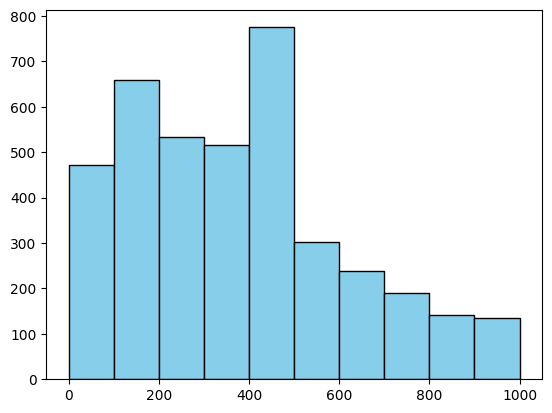

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/datasets/everpeak_clean.csv')

# Graficar histograma
counts, bin_edges, _ = plt.hist(df['price'], bins=10, range=(0, 1000), color='skyblue', edgecolor='black')

## Práctica Guiada 2: Distribución de edades de clientes
Objetivo: El equipo quiere entender la distribución de las edades de los clientes (customer_age) para segmentar mejor las estrategias de marketing.

Instrucciones

Grafica un histograma de la columna customer_age.

Usa exactamente 10 rangos (bins) para dividir las edades.
No ajustes el rango (range) si todas las edades son visibles.
Usa: color='skyblue' y edgecolor='black'.
Muestra las etiquetas de los rangos (bins) en el eje X.
Agrega título y etiquetas al gráfico (puedes copiarlos de aquí):
Eje X: "Edades de los Clientes"
Eje Y: "Cantidad"
Título: "Distribución de Edades"

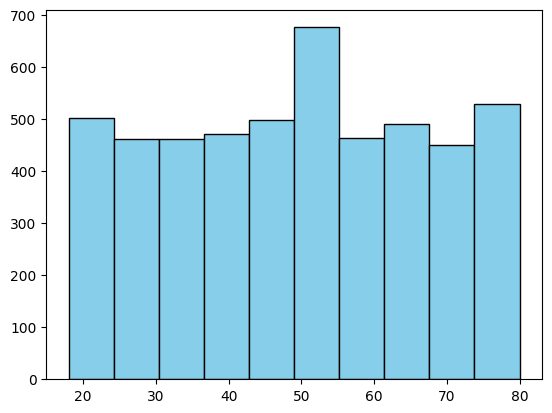

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/datasets/everpeak_clean.csv')

# Graficar histograma
counts, bin_edges, _ = plt.hist(df['customer_age'], bins=10, color='skyblue', edgecolor='black')

## Práctica Guiada 1: Analizando la distribución de precios
Objetivo: El equipo de Inteligencia Comercial quiere entender cómo se distribuyen los precios y detectar posibles valores atípicos que puedan afectar los análisis.

Instrucciones

Grafica un histograma de la columna price.

Ajusta el rango para enfocarte en los precios entre 0 y 1000.
Divide los precios en 10 rangos.
Usa: color='skyblue' y edgecolor='black'.
Muestra las etiquetas de los rangos (bins).
Agrega los siguientes título y etiquetas (puedes copiarlos directamente de aquí):
Título: "Distribución de Precios"
Etiqueta eje X: "Precio"
Etiqueta eje Y: "Cantidad"

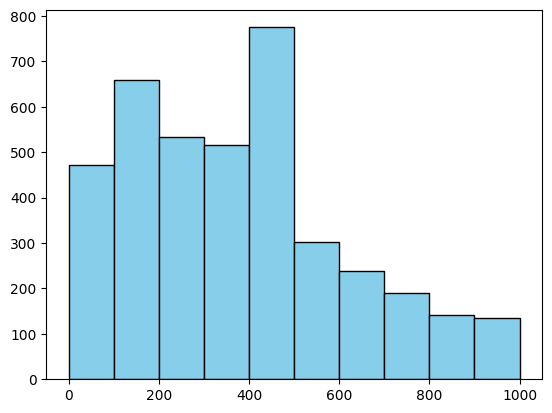

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/datasets/everpeak_clean.csv')

# Graficar histograma
counts, bin_edges, _ = plt.hist(df['price'], bins=10, range=(0, 1000), color='skyblue', edgecolor='black')

## Práctica Guiada 2: Explorando la dispersión de cantidades con Boxplot
Objetivo: El equipo de Inteligencia Comercial necesita analizar cómo se distribuyen las cantidades compradas (quantity) dentro de la categoría "Toys", para detectar valores extremos que podrían afectar decisiones de inventario y logística.

Instrucciones

Filtra el dataset para quedarte solo con la categoría “Toys”.
Grafica un boxplot de la columna quantity.
Usa el color 'skyblue'.
Asegúrate de incluir título y etiqueta del eje (puedes copiarlos de aquí):
Eje X: "Cantidad Comprada"
Título: "Boxplot de Cantidades - Categoría Toys"

<AxesSubplot:xlabel='quantity'>

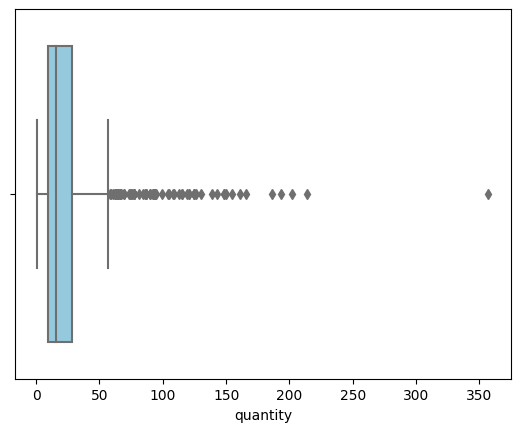

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/datasets/everpeak_clean.csv')
df_toys = df[df['product_category'] == 'Toys']

# Graficar BoxPlot
sns.boxplot(x=df_toys['quantity'], color='skyblue')

## Práctica Guiada 3: Distribución de edades de clientes
Objetivo: El equipo quiere entender la distribución de las edades de los clientes (customer_age) para segmentar mejor las estrategias de marketing.

Instrucciones

Grafica un histograma de la columna customer_age.

Usa exactamente 10 rangos (bins) para dividir las edades.
No ajustes el rango (range) si todas las edades son visibles.
Usa: color='skyblue' y edgecolor='black'.
Muestra las etiquetas de los rangos (bins) en el eje X.
Agrega título y etiquetas al gráfico (puedes copiarlos de aquí):
Eje X: "Edades de los Clientes"
Eje Y: "Cantidad"
Título: "Distribución de Edades"

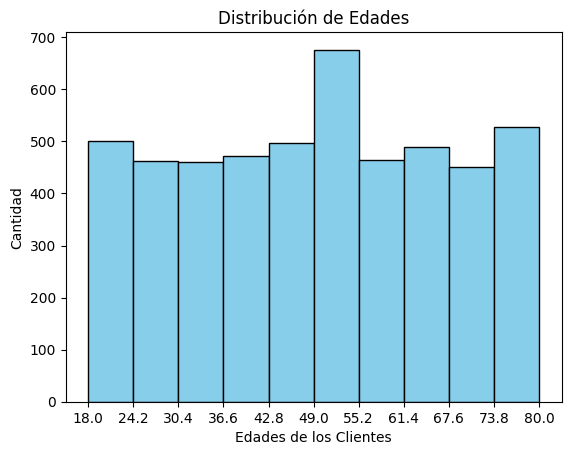

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/datasets/everpeak_clean.csv')

# Graficar histograma
counts, bin_edges, _ = plt.hist(df['customer_age'], bins=10, color='skyblue', edgecolor='black')

# Mostrar las marcas de los bins en el eje X
plt.xticks(bin_edges)

# Etiquetas y título del gráfico
plt.xlabel("Edades de los Clientes")
plt.ylabel("Cantidad")
plt.title("Distribución de Edades")
plt.show()

## Práctica Guiada 4: Boxplot del valor total de pedidos
Objetivo: El equipo necesita analizar cuánto gastan los clientes en las categorías “Fashion” y “Sports”, evaluando la dispersión del order_value y detectando posibles outliers que puedan afectar decisiones de negocio.

Instrucciones

Crea dos datasets para quedarte solo con las categorías “Fashion” y “Sports”.
Grafica un boxplot de la columna order_value para cada categoría por separado.
Usa color 'skyblue' en ambos.
Asegúrate de incluir título y etiqueta del eje (puedes copiarlos de aquí):
Eje X: "Gasto del Cliente"
Títulos (según corresponda):
"Boxplot de Gastos - Categoría Fashion"
"Boxplot de Gastos - Categoría Sports"

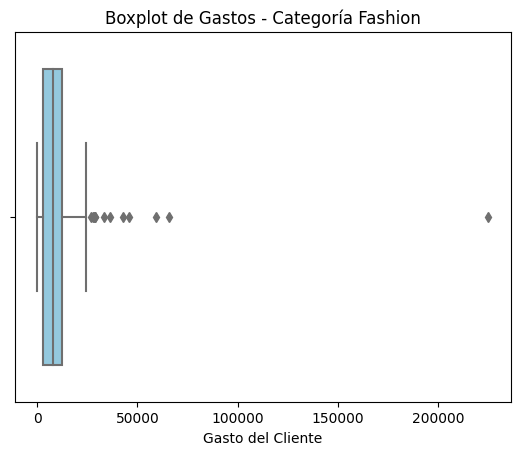

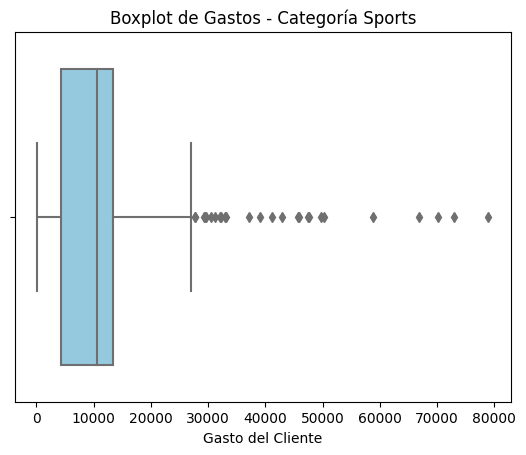

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/datasets/everpeak_clean.csv')

# Filtrar datos
df_fashion = df[df['product_category'] == 'Fashion']
df_sports = df[df['product_category'] == 'Sports']

# BoxPlot Categoría Fashion
sns.boxplot(x=df_fashion['order_value'], color='skyblue')
plt.xlabel("Gasto del Cliente")
plt.title("Boxplot de Gastos - Categoría Fashion")
plt.show()

# BoxPlot Categoría Sports
sns.boxplot(x=df_sports['order_value'], color='skyblue')
plt.xlabel("Gasto del Cliente")
plt.title("Boxplot de Gastos - Categoría Sports")
plt.show()

## Práctica Guiada 1 — Detectar outliers con IQR
🎯 Objetivo: Identificar outliers en order_value con IQR.

📋 Instrucciones

Calcula Q1, Q3 e IQR.
Calcula los límites inferior y superior.
Muestra los resultados:
Completa el código haciendo un filtrado para mostrar los registros que estén por debajo o por arriba de los límites inferior y superior, respectivamente.

In [40]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_clean.csv")

# calcular Q1, Q3 e IQR
Q1 = df['order_value'].quantile(0.25)
Q3 = df['order_value'].quantile(0.75)
IQR = Q3 - Q1

# calcular límite inferior y superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Mostrar resultados
print('Primer cuartil: ', Q1)
print('Tercer cuartil: ', Q3)
print('IQR: ', IQR)

print("\nRegistros abajo del límite inferior")
print(df[df['order_value'] < limite_inferior])

print("\nRegistros arriba del límite superior")
print(df[df['order_value'] > limite_superior])

Primer cuartil:  3094.0
Tercer cuartil:  13160.5
IQR:  10066.5

Registros abajo del límite inferior
Empty DataFrame
Columns: [order_id, order_date, customer_id, product_category, price, quantity, order_value, payment_method, city, state, customer_age, quantity_invalid_flag, age_invalid_flag, state_missing_flag]
Index: []

Registros arriba del límite superior
      order_id  order_date  customer_id product_category  price  quantity  \
8            9  2024-03-14         2925           Beauty     55       833   
123        124  2024-06-21         1389      Electronics   1947        16   
155        156  2024-08-30         2901          Grocery     36      1278   
199        200  2024-12-18         2919          Fashion   5174         7   
265        266  2024-07-31         1905      Electronics   2897        10   
...        ...         ...          ...              ...    ...       ...   
4934      4935  2024-05-19         1502      Electronics   4282        11   
4936      4937  2024-12

## 🧭 Práctica Guiada 2 — Z-scores
🎯 Objetivo: Identificar outliers en order_value usando Z-Score.

📋 Instrucciones

Calcula mean, std y z-score para order_value.
Filtra los registros con |z| > 3 y muestra cuántos outliers aparecen.

In [41]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_clean.csv")

#cálculo de la media
mean = df['order_value'].mean()

#cálculo de la desviación estándar
std = df['order_value'].std()

#Crea el z score
df['z'] = (df['order_value'] - mean) / std

#Calcula los valores extremos
print(df[df['z'].abs() > 3])

      order_id  order_date  customer_id product_category  price  quantity  \
293        294  2024-05-01         2149      Electronics   3336        17   
369        370  2024-10-09         2784      Electronics   5973        13   
375        376  2024-02-04         2285      Electronics   4782        20   
391        392  2024-03-06         2981      Electronics   2463        20   
397        398  2024-03-12         2024      Electronics   4893        18   
...        ...         ...          ...              ...    ...       ...   
4698      4699  2024-04-20         2059      Electronics   5227        11   
4732      4733  2024-10-06         2685           Sports   3394        14   
4908      4909  2024-10-19         1119      Electronics   3927        19   
4921      4922  2024-11-15         1621           Sports   2765        18   
4942      4943  2024-11-02         1979      Electronics   6478        11   

      order_value payment_method      city    state  customer_age  \
293   

## 🧩 Práctica Individual 1 — Comparar métodos en price
🎯 Objetivo: Comparar métodos IQR y Z-Score en la columna price. 

📋 Instrucciones

Calcula Q1, Q3 e IQR.
Calcula la media, la desviación estándar y el Z-score.
Finalmente, muestra y compara los resultados; para ello:
Usando el IQR, en una sola línea filtra los registros donde se cumpla la condición de que los valores en price están por debajo o por encima del límite inferior y superior.
Filtra los outliers marcados por el Z-score

In [42]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_clean.csv")

# ----- IQR -----
# calcular Q1, Q3 e IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1


# calcular límite inferior y superior
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# ----- Z-score -----
# calcular media, desviación estándar y z-score
mean = df['price'].mean()
std = df['price'].std()
df['z'] = (df['price'] - mean) / std

# ----- Mostrar resultados -----
print('Outliers usando IQR:')
print(df[(df['price'] < lower) | (df['price'] > upper)])

print('\nOutliers usando Z-Score:')
print(df[df['z'].abs() > 3])

Outliers usando IQR:
      order_id  order_date  customer_id product_category  price  quantity  \
64          65  2024-05-30         1651           Sports   2106         5   
67          68  2024-05-15         2385             Home   5181         4   
95          96  2024-04-15         2991           Sports   1940         4   
123        124  2024-06-21         1389      Electronics   1947        16   
138        139  2024-05-07         2274      Electronics   2437         6   
...        ...         ...          ...              ...    ...       ...   
4955      4956  2024-03-11         2230      Electronics   3824         6   
4974      4975  2024-10-20         2627      Electronics   1985         6   
4984      4985  2024-03-11         2509           Sports   1911         4   
4990      4991  2024-08-25         2569           Sports   2856         5   
4997      4998  2024-10-26         2838      Electronics   2699         4   

      order_value payment_method         city    state

## 🧭 Práctica Guiada 1 — Escribir tu primer IF-ELSE
🎯 Objetivo: La gerencia de marketing nos ha pedido crear una regla que indique si los clientes en general superan cierto volumen de compra.

📋 Instrucciones:

Clasifica las ventas en 2 segmentos, tomando en cuenta media y mediana.

Clasificar con media o promedio:
Calcula el promedio de la columna "quantity".
Crea una condición,
Si la compra es mayor a 22 unidades, imprimimos "En promedio: volumen alto".
Si no, "En promedio: volumen bajo".
Clasificar con mediana:
Calcula la mediana de la columna "quantity".
Crea una condición,
Si la compra es mayor a 22 unidades, imprimimos "Según la mediana: volumen alto".
Si no, "Según la mediana: volumen bajo".

In [43]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_clean.csv")

# Calcular promedio y mediana
cantidad_promedio = df['quantity'].mean()
cantidad_mediana = df['quantity'].median()
print("Promedio:", cantidad_promedio)
print("Mediana:",cantidad_mediana)
print() # salto de línea

# Segmentación con media o promedio
if cantidad_promedio > 22:
    print("En promedio: volumen alto")
else: 
    print("En promedio: volumen bajo")
	
# Segmentación con mediana
if cantidad_mediana > 22:
    print("Según la mediana: volumen alto")
else:
    print("Según la mediana: volumen bajo")

Promedio: 32.3598
Mediana: 14.0

En promedio: volumen alto
Según la mediana: volumen bajo


## 🧭 Práctica Individual 1 — Mejorar tu primer IF-ELSE
🎯 Objetivo: La gerencia de marketing nos ha pedido mejorar la regla anterior agregando una tercera categoría.

📋 Instrucciones:

Crea una nueva condición para el promedio. 
 Si la compra es mayor o igual a 10 unidades, imprimimos "En promedio: volumen medio".
Crea una nueva condición para la mediana. 
 Si la compra es mayor o igual a 10 unidades, imprimimos "Según la mediana: volumen medio".

In [44]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_clean.csv")

# Calcular promedio y mediana
cantidad_promedio = df['quantity'].mean()
cantidad_mediana = df['quantity'].median()
print("Promedio:", cantidad_promedio)
print("Mediana:",cantidad_mediana)
print()

# Segmentación con media o promedio
if cantidad_promedio > 22:
	print("En promedio: volumen alto")
elif cantidad_promedio >= 10:
	print("En promedio: volumen medio")

else: 
	print("En promedio: volumen bajo")
	
# Segmentación con mediana
if cantidad_mediana > 22:
	print("Según la mediana: volumen alto")
elif cantidad_mediana >= 10:
	print("Según la mediana: volumen medio")

else: 
	print("Según la mediana: volumen bajo")

Promedio: 32.3598
Mediana: 14.0

En promedio: volumen alto
Según la mediana: volumen medio


## 🧭 Práctica Guiada 1 — Segmentación básica con np.where()
🎯 Objetivo: La gerencia de marketing nos ha pedido segmentar a los clientes por volumen de compra.

📋 Instrucciones:

Crea una columna volume_segment que clasifique a los clientes por su volumen de compra usando np.where():
La condición debe revisar si quantity es mayor a 22.
Si la condición se cumple, asignamos "High Volume".
Si la condición no se cumple, asignamos "Low Volume".

In [45]:
import pandas as pd
import numpy as np
df = pd.read_csv("/datasets/everpeak_clean.csv")

# Crear columna nueva
df["volume_segment"] = np.where(df["quantity"] > 22, "High Volume", "Low Volume")


# Verificar cambios
print(df['volume_segment'].value_counts())

Low Volume     3739
High Volume    1261
Name: volume_segment, dtype: int64


## 🧭 Práctica Guiada 2 — Segmentación avanzada con función y apply
🎯 Objetivo: La gerencia de marketing nos ha pedido segmentar los clientes por edad y por volumen de compra, separando en 4 segmentos.

📋 Instrucciones:

Escribe una función classify_volume() que reciba row como parámetro.
Extrae customer_age y quantity del renglón.
Crea las reglas para separar en 4 segmentos:
Más de 22 unidades y más de 55 años → "Sr. High Volume"
Más de 22 unidades y menor o igual a 55 años → "Jr. High Volume"
Menor o igual a 22 unidades y más de 55 años → "Sr. Low Volume"
Menor o igual a 22 unidades y menor o igual a 55 años → "Jr. Low Volume"
Retorna el segmento.
Aplica la función y verifica los cambios.

In [46]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_clean.csv")

def classify_volume(row):
    age = row['customer_age']  # extrae la edad
    qty = row['quantity']      # extrae la cantidad de compra

    # 1. Manejo de valores nulos/faltantes
    # pd.isna() verifica de forma robusta si el valor es NaN
    if pd.isna(age) or pd.isna(qty):
        return "Error en Datos"

    # --- 2. Segmentación de Altas Cantidades ---
    if qty > 22:
        if age > 55: # Completa el código: revisar edad mayor a 55 años
            return "Sr. High Volume" # Completa el código
        else: # age <= 55
            return "Jr. High Volume" # Completa el código
            
    # --- 3. Segmentación Bajas Cantidades ---
    elif qty <= 22: # Completa el código: revisar cantidad menor o igual a 22
        if age > 55: # Completa el código: revisar edad mayor a 55 años
            return "Sr. Low Volume" # Completa el código
        else: # age < 55
            return "Jr. Low Volume" # Completa el código

# aplicar función y verificar cambios
df["volume_segment"] = df.apply(classify_volume, axis=1) # Completa el código
print(df['volume_segment'].value_counts())

Jr. Low Volume     3004
Sr. High Volume    1197
Sr. Low Volume      735
Jr. High Volume      64
Name: volume_segment, dtype: int64


## 🧩 Práctica Individual 1 — Segmentación avanzada con función y apply
🎯 Objetivo: La gerencia de finanzas nos ha solicitado segmentar las transacciones según el método de pago y el volumen de compra, para analizar patrones de pago en compras altas y bajas.

📋 Instrucciones:

Escribe una función classify_payment() que reciba row como parámetro.
Extrae payment_method y quantity del renglón.
Crea las reglas de segmentación considerando:
Altas cantidades: más de 22 unidades.
Bajas cantidades: 22 unidades o menos.
Métodos con tarjeta: revisar igualdad con credit_card o debit_card.
Clasifica cada transacción en uno de los siguientes segmentos:
"card_high_volume"
"no_card_high_volume"
"card_low_volume"
"no_card_low_volume"
Retorna el segmento correspondiente.
Aplica la función y verifica los cambios.

In [47]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

def classify_payment(row):
    card = row['payment_method'] # Completa el código
    qty = row['quantity'] # Completa el código

    # 1. Manejo de valores nulos/faltantes
    if pd.isna(card) or pd.isna(qty):
        return "Error en Datos"

    # --- 2. Segmentación de Altas Cantidades ---
    if qty > 22:
        if card in ["credit_card", "debit_card"]: # Completa el código
            return "card_high_volume" # Completa el código
        else: 
            return "no_card_high_volume" # Completa el código
            
    # --- 3. Segmentación Bajas Cantidades ---
    elif qty <= 22:
        if card in ["credit_card", "debit_card"]: # Completa el código
            return "card_low_volume" # Completa el código
        else: 
            return "no_card_low_volume" # Completa el código

# aplicar función y verificar cambios
df['payment_segment'] = df.apply(classify_payment, axis=1) # Completa el código
print(df['payment_segment'].value_counts())

card_low_volume        2725
no_card_low_volume     1041
card_high_volume        909
no_card_high_volume     333
Name: payment_segment, dtype: int64
